In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('.'))

from xso.parscans import run_xso_parscan,run_xso_stabilityscan

from cariaco_ssm_setup import model, model_setup, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup, extract_steady_state_seed,
)
from parscan_plots import (
    plot_cost_heatmap,
    plot_model_vs_obs_boxplots, summarize_best_fit,
)

In [2]:
REGIME = 'all'
obs_vec, labels, bin_defs, monthly_df, forcing = load_cariaco_targets(regime=REGIME)

print(f"Observation targets (regime='{REGIME}'):")
for lab, val in zip(labels, obs_vec):
    print(f"  {lab:20s}: {val:.5f}")
print(f"Months in filtered dataset: {len(monthly_df)}")
print(f"Regime forcing:")
print(f"  Inflow__FN = {forcing['Inflow__FN']:.4f}  mmol N m-2 d-1")
print(f"  Inflow__de = {forcing['Inflow__de']:.2f}  m")
print(f"  (F_N/d_e   = {forcing['Inflow__FN']/forcing['Inflow__de']:.6f}  mmol N m-3 d-1)")

Observation targets (regime='all'):
  Pico (<2 µm)        : 0.09698
  Nano (2-20 µm)      : 0.08512
  Micro (>20 µm)      : 0.19977
  Zoo >200 µm         : 0.05938
  Zoo >500 µm         : 0.03302
  NO3                 : 1.46705
  PP                  : 0.43247
  Export              : 3.18267
Months in filtered dataset: 255
Regime forcing:
  Inflow__FN = 2.6834  mmol N m-2 d-1
  Inflow__de = 45.58  m
  (F_N/d_e   = 0.058877  mmol N m-3 d-1)


In [3]:
# CLEAN BASELINE — literature defaults only, with FN scanned out of forcing.
# All other parameters at cariaco_ssm_setup.py defaults (KsZ=3.0,
# fish_rate=0.005, f_egest_D=0.75, k_remin=0.1, f_mort_D=0.9 phyto / 0.5 zoo).

forcing.pop('Inflow__FN', None)

2.683443513598565

In [4]:
# FN × GGE — productivity vs. trophic efficiency.
# - FN extended to 30 mmol N m⁻² d⁻¹ on top end so the spectrum-best is
#   not bound-pinned (extended FN×KsZ scan landed at FN=22.5).
# - GGE spans full Stock 2008 LP–HP range, linear sampling.
# Asks: at what (if any) productivity does GGE actually move the
# spectrum? Or is GGE flat across the entire productivity axis?
P1_NAME   = 'Inflow__FN'
P1_LABEL  = 'New nutrient flux F_N (mmol N m⁻² d⁻¹)'
P1_VALUES = np.logspace(np.log10(0.5), np.log10(30.0), 150)
P2_NAME   = 'GGE__gge'
P2_LABEL  = 'Gross growth efficiency (GGE)'
P2_VALUES = np.linspace(0.05, 0.55, 150)
# Scan runtime settings
N_PROCESSES = 20
AVG_WINDOW  = 1000
print(f"2D scan: {P1_NAME} ({len(P1_VALUES)} pts)  x  {P2_NAME} ({len(P2_VALUES)} pts)")
print(f"Total runs: {len(P1_VALUES) * len(P2_VALUES)}")
print(f"  FN spans {P1_VALUES.min():.3f} – {P1_VALUES.max():.3f} mmol N m⁻² d⁻¹ "
      f"(log-spaced; brackets CARIACO regimes; 'all'-mean ≈ 2.67)")
print(f"  GGE spans {P2_VALUES.min():.3f} – {P2_VALUES.max():.3f} "
      f"(linear; Stock 2008 LP–HP range)")

2D scan: Inflow__FN (150 pts)  x  GGE__gge (150 pts)
Total runs: 22500
  FN spans 0.500 – 30.000 mmol N m⁻² d⁻¹ (log-spaced; brackets CARIACO regimes; 'all'-mean ≈ 2.67)
  GGE spans 0.050 – 0.550 (linear; Stock 2008 LP–HP range)


In [5]:
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_slim',
    param_name=P1_NAME,
    param_values=P1_VALUES,
    param_name2=P2_NAME,
    param_values2=P2_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': AVG_WINDOW},
)

PROGRESS: Completed 150/150 outer points. (Inflow__FN = 29.999999999999996).

2D Scan complete. Total Time taken: 2229.55245 seconds.


In [6]:
print(scan_results)

<xarray.Dataset> Size: 39MB
Dimensions:                         (GGE__gge: 150, Inflow__FN: 150, time: 1,
                                     phyto: 12, zoo: 12)
Coordinates:
  * GGE__gge                        (GGE__gge) float64 1kB 0.05 0.05336 ... 0.55
  * Inflow__FN                      (Inflow__FN) float64 1kB 0.5 0.5139 ... 30.0
  * time                            (time) float64 8B 4.999e+03
  * phyto                           (phyto) float64 96B 0.5 0.862 ... 200.0
  * zoo                             (zoo) float64 96B 5.0 8.62 ... 2e+03
    Inflow__de                      float64 8B 45.58
Data variables: (12/61)
    DetritusSink__sinking_value     (GGE__gge, Inflow__FN, time) float64 180kB ...
    Detritus__value                 (GGE__gge, Inflow__FN, time) float64 180kB ...
    Growth__uptake_value            (GGE__gge, Inflow__FN, time, phyto) float64 2MB ...
    Nutrient__value                 (GGE__gge, Inflow__FN, time) float64 180kB ...
    Phytoplankton__biomass         

In [7]:
seed_ds, iv_map = extract_steady_state_seed(scan_results, avg_window=AVG_WINDOW)


stability_results = run_xso_stabilityscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_stability',
    param_name=P1_NAME,
    param_values=P1_VALUES,
    param_name2=P2_NAME,
    param_values2=P2_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
    initial_values_ds=seed_ds,
    iv_mapping=iv_map,
)

PROGRESS: Completed 150/150 outer points. (Inflow__FN = 29.999999999999996).

2D Stability Scan complete. Total Time taken: 82.72864 seconds.


In [8]:
cost_grid, model_grid = compute_cost_grid(
    stability_results,
    phyto_esd=phyto_esd,
    zoo_esd=zoo_esd,
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    dim1_name=P1_NAME,
    dim2_name=P2_NAME,    avg_window=None,
    neg_tolerance=1e-6,
    clip_small_negatives=True,
    require_stable=False,
)

In [9]:
best = find_best_fit(cost_grid, model_grid, scan_results, P1_NAME, P2_NAME)

default = {
    'val1': get_default_from_setup(model_setup, P1_NAME),
    'val2': get_default_from_setup(model_setup, P2_NAME),
}

title_info = (f"{P1_NAME}={best['val1']:.4f}, "
              f"{P2_NAME}={best['val2']:.4f}, "
              f"cost={best['cost']:.3f}")

print(f"\n--- Best fit ---")
print(f"  {P1_LABEL}: {best['val1']:.5f}")
print(f"  {P2_LABEL}: {best['val2']:.5f}")
print(f"  Cost (NRMSRE): {best['cost']:.4f}")


--- Best fit ---
  New nutrient flux F_N (mmol N m⁻² d⁻¹): 22.79199
  Gross growth efficiency (GGE): 0.55000
  Cost (NRMSRE): 0.7471


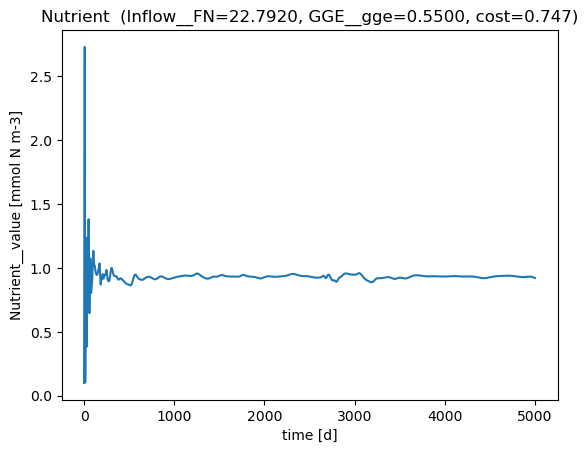

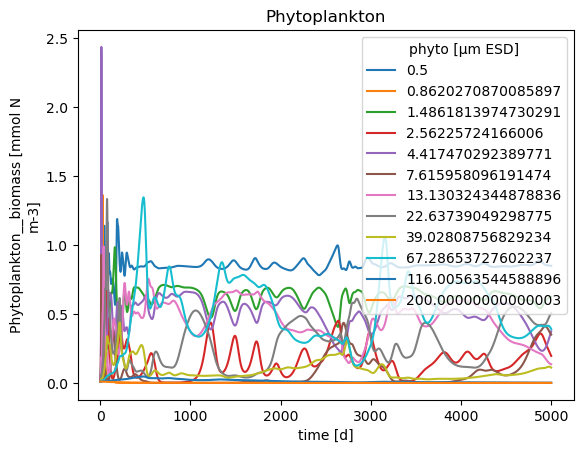

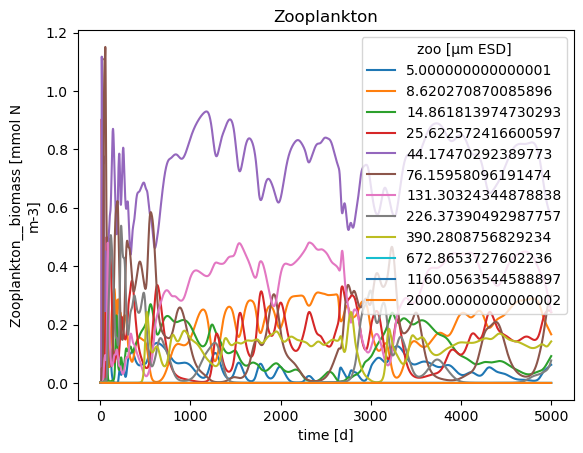

In [10]:
from cariaco_ssm_setup import model_setup_slim
from parscan_utils import run_single_point

best_run = run_single_point(
    model, model_setup_slim,
    scan_params={P1_NAME: best['val1'], P2_NAME: best['val2']},
    fixed_overrides=forcing,
)

best_run['Nutrient__value'].plot.line(x='time')
plt.title(f'Nutrient  ({title_info})')
plt.show()

best_run['Phytoplankton__biomass'].plot.line(x='time')
plt.title('Phytoplankton')
plt.show()

best_run['Zooplankton__biomass'].plot.line(x='time')
plt.title('Zooplankton')
plt.show()

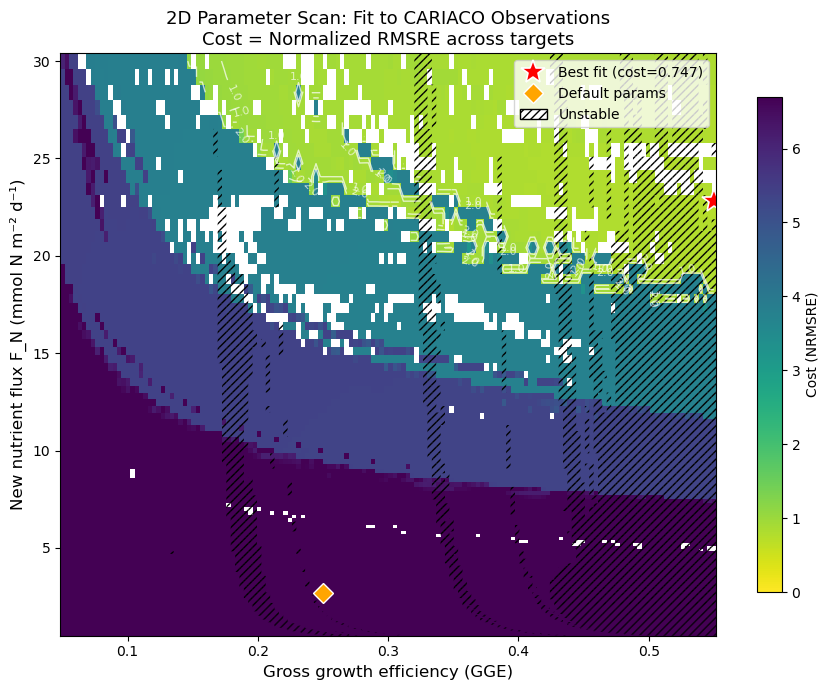

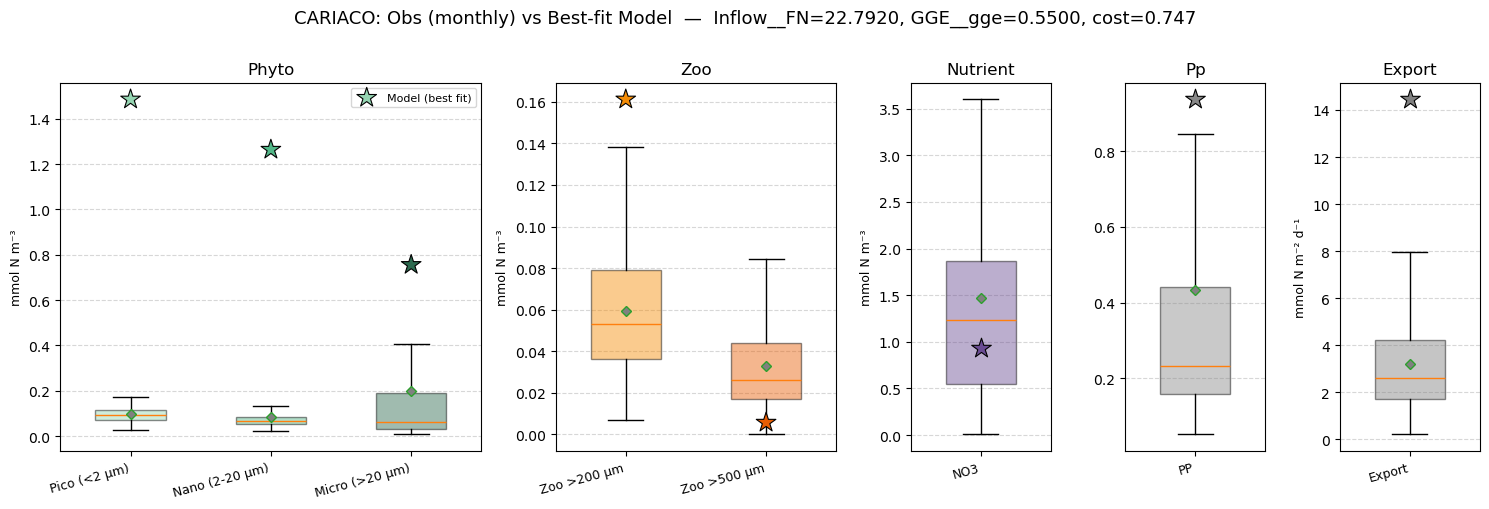

In [11]:
stable_mask = (stability_results['stability'] == 'stable').values

fig1 = plot_cost_heatmap(
    cost_grid, P1_VALUES, P2_VALUES, P1_LABEL, P2_LABEL, best,
    default=default,
    stable_mask=stable_mask,
)
plt.show()

fig3 = plot_model_vs_obs_boxplots(best['model_vec'], monthly_df, bin_defs,
                                  title_info=title_info)
plt.show()

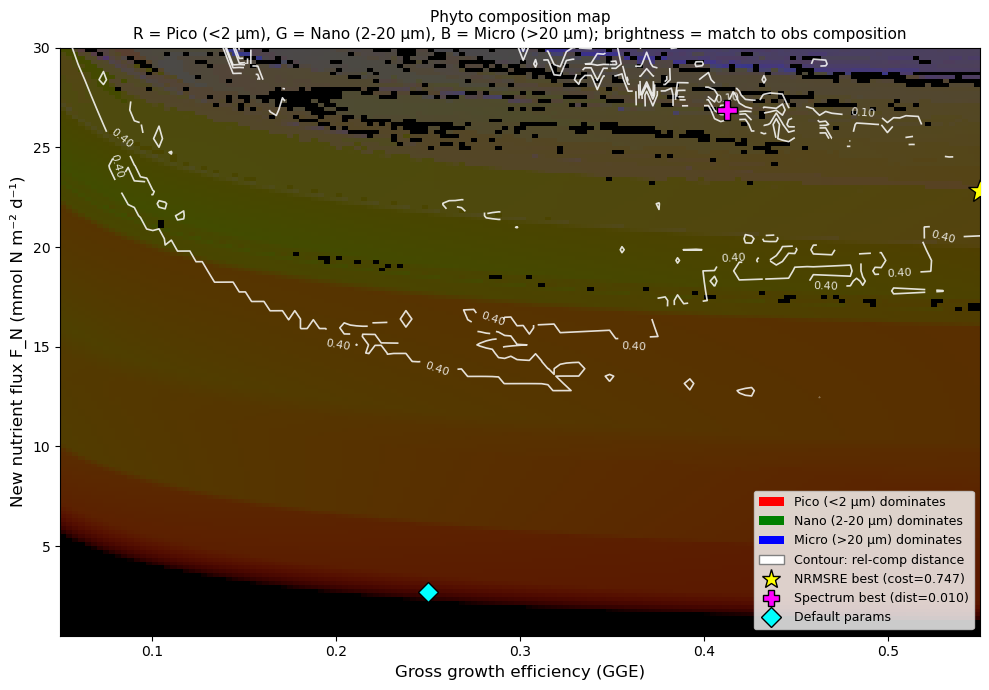

NRMSRE   best:  Inflow__FN=22.7920, GGE__gge=0.5500, cost=0.7471
Spectrum best:  Inflow__FN=26.8773, GGE__gge=0.4124, dist=0.0098


In [12]:
from parscan_utils import compute_spectrum_cost_grid
from parscan_plots import plot_spectrum_composition_map


# New: spectrum-only secondary cost
spectrum_cost_grid = compute_spectrum_cost_grid(
    model_grid, obs_vec, bin_defs, type_filter='phyto')
spectrum_best = find_best_fit(spectrum_cost_grid, model_grid,
                              scan_results, P1_NAME, P2_NAME)

# RGB composition map with both best-fit markers
fig_spec = plot_spectrum_composition_map(
    model_grid, obs_vec, bin_defs,
    P1_VALUES, P2_VALUES, P1_LABEL, P2_LABEL,
    best=best,
    spectrum_best=spectrum_best,
    default=default,
)
plt.show()

# Quick numerical readout of the two minima
print(f"NRMSRE   best:  {P1_NAME}={best['val1']:.4f}, "
      f"{P2_NAME}={best['val2']:.4f}, cost={best['cost']:.4f}")
print(f"Spectrum best:  {P1_NAME}={spectrum_best['val1']:.4f}, "
      f"{P2_NAME}={spectrum_best['val2']:.4f}, "
      f"dist={spectrum_best['cost']:.4f}")

In [13]:
from parscan_plots import summarize_best_fit
summarize_best_fit(
   model_vec=spectrum_best['model_vec'],
   obs_vec=obs_vec,
   labels=labels,
   cost=spectrum_best['cost'],
)


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 0.0098
     Component  Obs_Mean  Model_BestFit    Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        1.73995 17.94165   1694.16521
Nano (2-20 µm)   0.08512        1.44208 16.94251   1594.25098
Micro (>20 µm)   0.19977        3.52067 17.62400   1662.40037
   Zoo >200 µm   0.05938        0.16273  2.74063    174.06323
   Zoo >500 µm   0.03302        0.00634  0.19201    -80.79945
           NO3   1.46705        0.99041  0.67510    -32.48989
            PP   0.43247        1.20528  2.78696    178.69582
        Export   3.18267       19.57421  6.15026    515.02553


,Component,Obs_Mean,Model_BestFit,Ratio,Rel_Error_%
0,Pico (<2 µm),0.096978,1.739945,17.941652,1694.165207
1,Nano (2-20 µm),0.085116,1.442075,16.942510,1594.250985
2,Micro (>20 µm),0.199765,3.520666,17.624004,1662.400370
3,Zoo >200 µm,0.059377,0.162731,2.740632,174.063227
4,Zoo >500 µm,0.033023,0.006341,0.192005,-80.799451
5,NO3,1.467052,0.990408,0.675101,-32.489892
6,PP,0.432470,1.205275,2.786958,178.695818
7,Export,3.182666,19.574208,6.150255,515.025525


In [14]:
# Where do both costs sit in their respective "good" regions?
nrmsre_thresh   = np.nanpercentile(cost_grid, 10)            # bottom decile
spectrum_thresh = np.nanpercentile(spectrum_cost_grid, 10)
joint_good      = (cost_grid <= nrmsre_thresh) & \
                  (spectrum_cost_grid <= spectrum_thresh)
print(f"Cells satisfying both bottom-decile thresholds: "
      f"{joint_good.sum()} / {joint_good.size}")

Cells satisfying both bottom-decile thresholds: 1255 / 22500


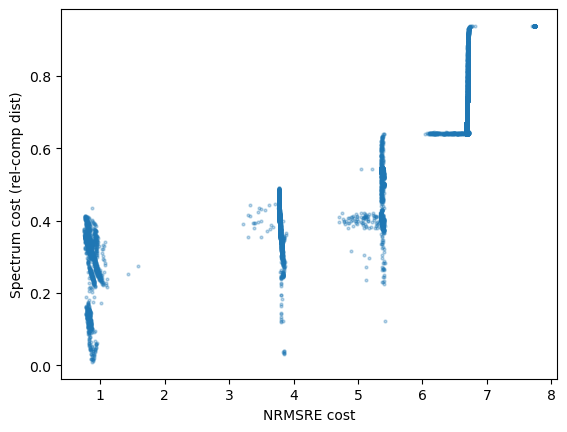

In [15]:
plt.scatter(cost_grid.ravel(), spectrum_cost_grid.ravel(),
            s=4, alpha=0.3)
plt.xlabel('NRMSRE cost'); plt.ylabel('Spectrum cost (rel-comp dist)')
plt.show()

In [16]:
# Source - https://stackoverflow.com/a/24542498
# Posted by ZSG, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-23, License - CC BY-SA 4.0

def fullprint(*args, **kwargs):
  from pprint import pprint
  import numpy
  opt = numpy.get_printoptions()
  numpy.set_printoptions(threshold=numpy.inf)
  pprint(*args, **kwargs)
  numpy.set_printoptions(**opt)


In [17]:
summary = summarize_best_fit(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    labels=labels,
    cost=best['cost'],
)


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 0.7471
     Component  Obs_Mean  Model_BestFit    Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        1.48558 15.31876   1431.87594
Nano (2-20 µm)   0.08512        1.26399 14.85022   1385.02170
Micro (>20 µm)   0.19977        0.75566  3.78276    278.27565
   Zoo >200 µm   0.05938        0.16118  2.71455    171.45533
   Zoo >500 µm   0.03302        0.00570  0.17259    -82.74147
           NO3   1.46705        0.93243  0.63558    -36.44212
            PP   0.43247        0.93715  2.16696    116.69608
        Export   3.18267       14.45245  4.54099    354.09889


In [18]:
best_run

<xarray.Dataset> Size: 2MB
Dimensions:                         (time: 5000, phyto: 12, zoo: 12, clock: 2)
Coordinates:
  * time                            (time) float64 40kB 0.0 1.0 ... 4.999e+03
  * phyto                           (phyto) float64 96B 0.5 0.862 ... 200.0
  * zoo                             (zoo) float64 96B 5.0 8.62 ... 2e+03
  * clock                           (clock) int64 16B 0 1
Data variables: (12/64)
    Core__solver_type               <U9 36B 'solve_ivp'
    DetritusRemin__detritus         <U1 4B 'D'
    DetritusRemin__k_remin          float64 8B 0.1
    DetritusRemin__nutrient         <U1 4B 'N'
    DetritusSink__detritus          <U1 4B 'D'
    DetritusSink__sinking_rate      float64 8B 0.1
    ...                              ...
    ZooMortality__rate              float64 8B 0.1
    Zooplankton__biomass            (zoo, time) float64 480kB 0.001 ... 0.0
    Zooplankton__biomass_init       (zoo) float64 96B 0.001 0.001 ... 0.001
    Zooplankton__biomass_label      <U1 4B 'Z'
    Zooplankton__zoo_esd_index      (zoo) float64 96B 5.0 8.62 ... 2e+03
    Zooplankton__zoo_esd_label      <U7 28B 'zoo_esd'

In [19]:
cell = stability_results.sel({P1_NAME: best['val1'], P2_NAME: best['val2']},
                             method='nearest').isel(time=-1)

# Volumetric rates [mmol N m-3 d-1]
FN_per_de  = float(cell['Inflow__FN']) / float(cell['Inflow__de'])
export_vol = float(cell['DetritusSink__sinking_value'])
fish_P     = float(cell['FishGrazing__fish_graze_phyto_value'].sum('phyto'))
fish_Z     = float(cell['FishGrazing__fish_graze_zoo_value'].sum('zoo'))
zoo_closure_export = float(cell['ZooMortality__mortality_value'].sum('zoo')) \
                   - float(cell['ZooMortality__mortality_to_D_value'])

lhs = FN_per_de
rhs = export_vol + fish_P + fish_Z + zoo_closure_export
print(f"F_N/d_e     = {lhs:.6f}")
print(f"Losses sum  = {rhs:.6f}")
print(f"  sinking       : {export_vol:.6f}")
print(f"  fish on P     : {fish_P:.6f}")
print(f"  fish on Z     : {fish_Z:.6f}")
print(f"  zoo closure   : {zoo_closure_export:.6f}")
print(f"Residual    = {lhs-rhs:.2e}")

# And the f-ratio interpretation:
pp_total = float(cell['Growth__uptake_value'].sum('phyto'))
print(f"\nTotal PP    = {pp_total:.6f}")
print(f"New PP      = {FN_per_de:.6f}  (≡ F_N/d_e)")
print(f"Regen PP    = {pp_total - FN_per_de:.6f}")
print(f"f-ratio     = {FN_per_de / pp_total:.3f}")

F_N/d_e     = 0.500079
Losses sum  = 0.500079
  sinking       : 0.317101
  fish on P     : 0.000309
  fish on Z     : 0.000603
  zoo closure   : 0.182066
Residual    = 1.11e-16

Total PP    = 0.937145
New PP      = 0.500079  (≡ F_N/d_e)
Regen PP    = 0.437066
f-ratio     = 0.534
